# <span style="color:blue;font-weight:bold;font-size:1.1em">Day 9: Probability</span>

In this notebook we will go over:

- Definition of probability.
- Theoretical and empirical probability.
- The normal distribution (bell curve) and other important distributions.
- Probability calculations with the normal distribution.

### <span style="color:blue;font-weight:bold;font-size:1.1em">Warning & Reminder to both Students and Instructors</span>

This is not a probability course, it is a statistics course.  Statistics uses probability, like a carpenter uses a hammer.  A carpenter doesn't need to know how to make his own hammer, he just has to know how it works.  Likewise, we have many tools at our disposal that will calculate the probabilities we need as statisticians; there's is little need to make these probability calculations from scratch in practice.  In this notebook, we will spend some time learning to make probability calculations from scratch, like learning to forge our own hammers, but in the future we will simply use the "hammers" that Python provides.

In [2]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import scipy.stats as stats
from scipy.stats import gaussian_kde

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')
survey = Table.read_table('welcome_survey_v1.csv')

## <span style="color:blue;font-weight:bold;font-size:1.1em">Probability</span>

Let an **probability experiment** refer to a situation where you observe and record the outcome that depends upon a fixed probability rule, but you do not know in advance what it will be. This could be as simple as a coin flip or drawing cards from a standard well-shuffled deck of playing cards.  This might mean counting people or objects with special properties such as counting all people in a room wearing glasses or counting the red cars in a parking lot.  

If $E$ is an event that can occur when an experiment is conducted, then the probability of $E$ denoted $P(\,E\,)$, is a numerical measurement of how likely $E$ is to occur.  

Facts about probability

1. $0 \leq P(E) \leq 1$
2. The closer $P(E)$ is to 1, the more likely $E$ is to occur. If $P(E) = 1$, then $E$ is virtually guaranteed.
3. The closer $P(E)$ is to 0, the less likely $E$ is to occur. If $P(E) = 0$, then $E$ is virtually impossible.
4. If $E$ is an event, then "not E", denoted $\sim E$, is literally anything else that can happen that is not part of $E$, and $P(\sim E) = 1- P(\,E\,)$.

**Example 1**

Suppose an unfair coin is weighted so that $P(Heads) = \frac{2}{3}$. Find:$$P(Tails)$$

**Example 2**

Suppose a fair six sided die is rolled, what's the probablity of it showing either 3 or 5?

### <span style="color:blue;font-weight:bold;font-size:1.1em">Theoretical Probability vs Empirical Probability</span>

A **theoretical probability** is one that is based upon known probability rules and calculated mathematically. The two examples above are both theoretical probabilities.

An **empirical probability** is based on observed outcomes. Simulations can be conducted by-hand or with a computer. If I have an unfair coin that lands heads up more often than half the time, but I'm not sure exactly how often, I could flip that coin 100 times and count how often it lands heads up. If it lands heads up 60 times out of 100, then I'd estimate that $$P(Heads) \approx \frac{60}{100} = 0.6$$

I can also set up a computer the conduct a probability experiement repeatedly and find what happens.

## <span style="color:blue;font-weight:bold;font-size:1.1em">Distributions</span>

A **distribution** shows the chance of different possible outcomes for a random variable. It maps out all likely and unlikely results, and represents them. A **histogram** or **density plot** is often a good way to visualize the distribution and its key properties.

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example: Dice</span>

Seeing how this works is easier to understand with an example or two to lead the way.

In [3]:
die = Table().with_column('Face', np.arange(1, 7))
die

Face
1
2
3
4
5
6


### <span style="color:blue;font-weight:bold;font-size:1.1em">Sampling</span>

Let's have the **sample()** function draw ten times at random from this distribution simulating rolling a fair die 10 times.

In [4]:
die.sample(10)

Face
2
2
1
1
3
4
5
1
1
4


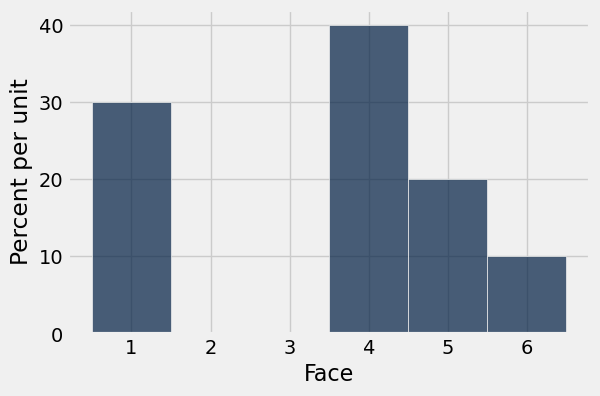

In [5]:
roll_bins = np.arange(0.5, 6.6, 1)
die.sample(10).hist(bins= roll_bins)

### <span style="color:blue;font-weight:bold;font-size:1.1em">Sampling Distributions</span>

Let's draw repeated samples of the same size $n$ but allow $n$ to increase. This will illustrate the **Central Limit Theorem** together with the **Law of Large Numbers**. Watch what happens as we increase sample size:
- $n = 100$
- $n = 1,000$
- $n = 100,000$


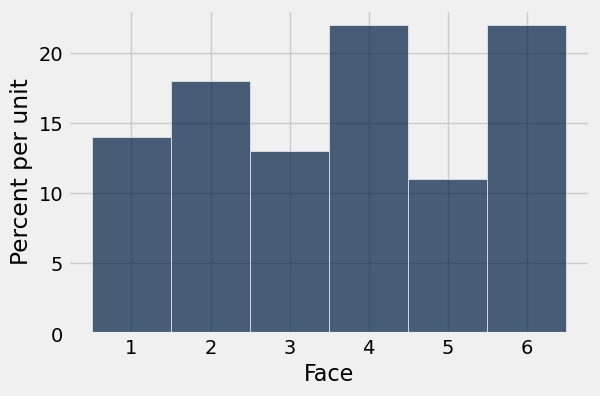

In [6]:
die.sample(100).hist(bins=roll_bins)   # One hundred samples.

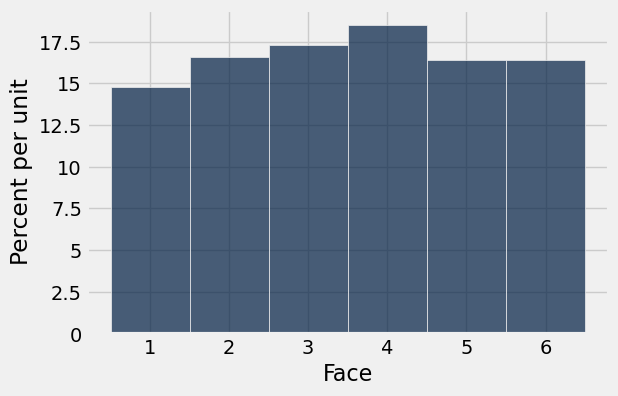

In [7]:
die.sample(1000).hist(bins=roll_bins)      # One thousand samples.

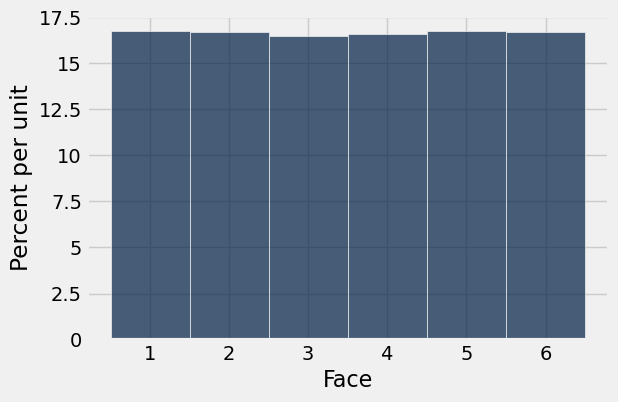

In [8]:
die.sample(100000).hist(bins=roll_bins)      # A hundred thousand samples.

## <span style="color:blue;font-weight:bold;font-size:1.1em">Consider a situation where we flip 10 fair coins and count the heads</span>

Th **binomial distribution** models coins flips and similar scenarios. The 10 flips are our *trials* and since the coin is assumed fair the probability of heads is $\frac{1}{2}$. 

Python has a function() <center><span style="color:red;font-weight:bold;font-size:1.1em">scipy.stats.binom.pmf()</span></center> that will model the coin flips for us. The inputs are:
1. Number of Successes
2. Number of Trials
3. Probability of Success

### <span style="font-weight:bold;font-size:1.1em">Practice Question: Find the probability of flipping fair coin 10 times and getting 5 heads."</span>

In [11]:
# The first example is shown below with correct inputs.

stats.binom.pmf(5, 10, 0.5)

0.24609375000000003

### <span style="font-size:1.1em">Practice Question: Find the probability of flipping fair coin 10 times and getting 5 or fewer heads.</span>

<span style="font-weight:bold;color:red;font-size:1.1em">Hint: Use np.arange()</span>

### <span style="font-size:1.1em">Practice Question: Find the probability of flipping fair coin 10 times and getting at least 1 heads.</span>

### <span style="font-weight:bold;font-size=1.1em">We graph the distribution below.</span>

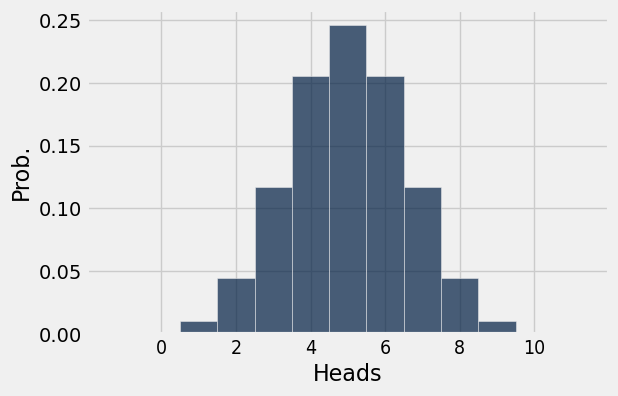

In [12]:
heads = np.arange(11)
pmf = stats.binom.pmf(heads, 10, 0.5)
Table().with_columns("Heads", heads, "Prob.", pmf).bar("Heads")

## <span style="color:blue;font-weight:bold;font-size:1.1em">Consider a situation where we roll a fair die 20 times and count the fives</span>

This is again the binomial distribution, this time with the number of trials being 20 and the probability of success:$$p(s) = \frac{1}{6}$$
## <span style="color:blue;font-weight:bold;font-size:1.1em">Suppose we roll a fair 6 sided die 20 times and count the number of 5's</span>

Once again, the **binomial distribution** models the scenario with 20 **trials**. 


### <span style="font-weight:bold;font-size:1.1em">Practice Questions: If we roll a fair die 20 times, find the following:"</span>
- The probability of exactly 12 5's.
- The probablity of 12 or more 5's.
- The probability of 2 5's?
- The probability of 2 or more 5's?

In [23]:
# P(12 5's)



In [24]:
# (12 or more 5's)



In [25]:
# P(2 5's)



In [26]:
# P(2 or more 5's)



### Graph of the pmf.

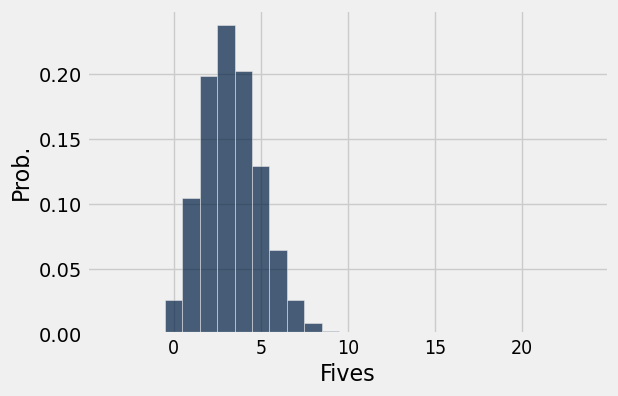

In [27]:
fives = np.arange(21)
pmf = stats.binom.pmf(fives, 20, 1/6)
Table().with_columns("Fives", fives, "Prob.", pmf).bar("Fives")

## <span style="color:blue;font-weight:bold;font-size:1.1em">Famous Example: The Lady Tasting Tea</span>

Dr. Muriel Bristol claimed to be able to tell the difference between two types of cups of tea:
- Tea first with cold milk poured on top
- Milk first then hot tea poured on top

Fellow scholars Ronald Fisher and William Roach did not believe her, so they devised an experiment to test her. Eight cups of tea were prepared, four of each type, and Muriel was presented them in random order. She had to sip them and identify whether they had been prepared with "milk first" or "tea first."

History records that she correctly identified all 8 cups.

Fischer realized he could calculate the exact probabilities for each number of successes given that he assumed Muriel was randomly guessing. This insight led to the idea of the **null hypothesis** which was to be disproven.

In [28]:
stats.binom.pmf(8, 4, 0.5)   # Four successes out of 8 trials

0.0

In [30]:
# 6 successes out of 8 trials



In [31]:
# 7 successes out of 8 trials



In [32]:
# 8 successes out of 8 trials



## <span style="color:blue;font-weight:bold;font-size:1.1em">Normal Distribution</span>

The normal distribution is common probability distribution, often used in statistics. The **Standard Normal** distribution has a mean of 0 and a standard deviation of 1.  It is denoted $$N(0, 1)$$.  

If the mean is $\mu$ and the standard deviation is $\sigma$, the notation $$N(\mu, \sigma)$$ refers to the normal distribution.  

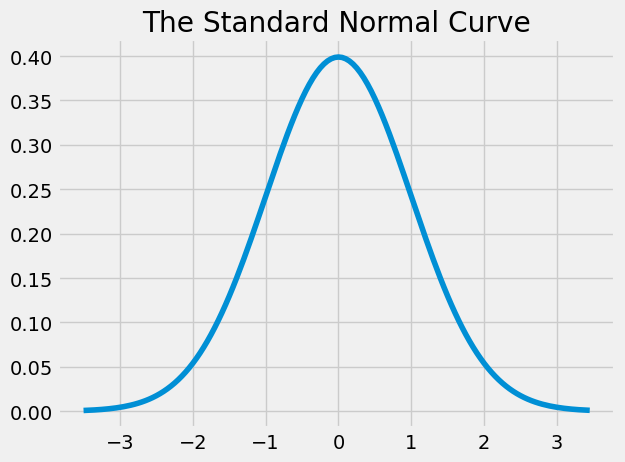

In [34]:
x = np.arange(-3.5, 3.5, 0.05)
y = stats.norm.pdf(x, 0, 1)
plots.plot(x, y)
plots.title("The Standard Normal Curve");

### <span style="color:blue;font-weight:bold;font-size:1.1em"> Standard Units</span>

In the context of a normal distribution, the idea of "standard unit" has another name, *z -score*.

$$ z = \frac{x - \mu}{\sigma}$$

When $\mu$ and $\sigma$ are unknown, and we're working with statistics from a sample the standard units are:

$$SU = \frac{x - \overline{x}}{s}$$


Converting to z-scores allows us to compare <u>any</u> normal distribution to the Standard Normal.


**Example** Fraternal twins Richard and Rachel are both unusually tall.  Richard is male and is 6'5'', while Rachel is female and 6'1''.  (These are 77 and 73 inches tall, respectively.)  Assume that the distribution of heights for males follows $N(69, 3)$, while the distribution of heights for females follows $N(64, 4)$, both in inches.  Settle a dispute between the two siblings: who is the <u>most</u> unusually tall?

This isn't simply, "who's the tallest?", the answer to that is obvious.  Rather, for the population they are each part of who is further out in the "tail" of the distribution?

**Solution:** Find both of their z-scores and compare those.

### <span style="color:blue;font-weight:bold;font-size:1.1em"> Empirical Rule</span>

The Empirical Rule gives us a way of understanding exactly how the standard deviation tells us how far the data spreads out around the mean.  Here's the rule in written form, but the graphs below probably show it in a way that makes more sense.

- 68% of <u>any</u> normal population will fall within 1 standard deviation of the mean
- 95% of <u>any</u> normal population will fall within 2 standard deviations of the mean.
- 99.7% of <u>any</u> normal population will fall within 3 standard deviations of the mean.  

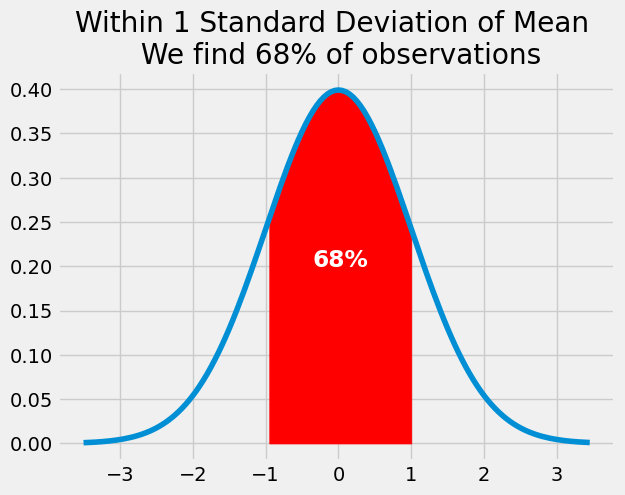

In [35]:
x = np.arange(-3.5, 3.5, 0.05)
y = stats.norm.pdf(x, 0, 1)
plots.plot(x, y)
plots.fill_between(x,y, where =abs(x)<1, color="red")
plots.text(-0.35, .2, "68%", color="white", weight="bold", size='large')
plots.title("Within 1 Standard Deviation of Mean \n We find 68% of observations");

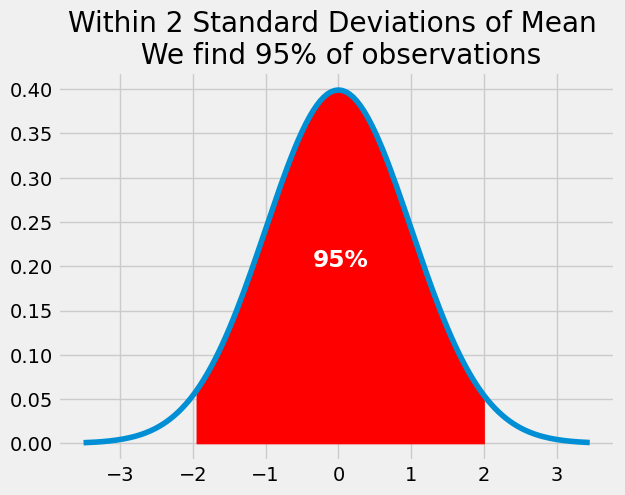

In [36]:
x = np.arange(-3.5, 3.5, 0.05)
y = stats.norm.pdf(x, 0, 1)
plots.plot(x, y)
plots.fill_between(x,y, where =abs(x)<=2, color="red")
plots.text(-0.35, .2, "95%", color="white", weight="bold", size="large")
plots.title("Within 2 Standard Deviations of Mean \n We find 95% of observations");

Text(0.5, 1.0, 'Within 3 Standard Deviations of Mean \n We find 99.7% of observations')

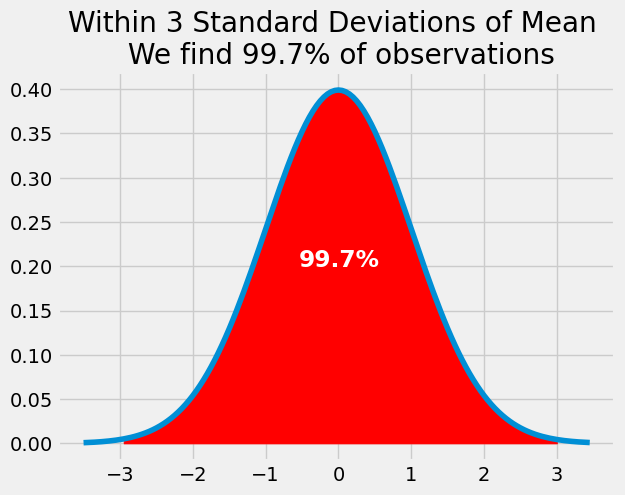

In [37]:
x = np.arange(-3.5, 3.5, 0.05)
y = stats.norm.pdf(x, 0, 1)
plots.plot(x, y)
plots.fill_between(x,y, where =abs(x)<3, color="red")
plots.text(-0.55, .2, "99.7%", color="white", weight="bold", size="large")
plots.title("Within 3 Standard Deviations of Mean \n We find 99.7% of observations")

So if you know that your data is normal, or just approximately normal, and you know the mean and standard deviation, you can quickly compute the upper and lower bounds that should capture all or nearly all of the data.

**Example:** If you're told that a sample of data is (approximately) normal with a mean of 50 and a standard deviation of 6, then you know that most (if not <u>all</u>) of that data is between $50 - 3\cdot 6 = 32$ and $50 + 3\cdot 6 = 68$. 

**Example:** Similarly, if $X$ is an observation from $N(50, 6)$, then the probability that $X$ is between 32 and 68 is 0.997, or 99.7%.  

It works this way with any normal population or distribution.

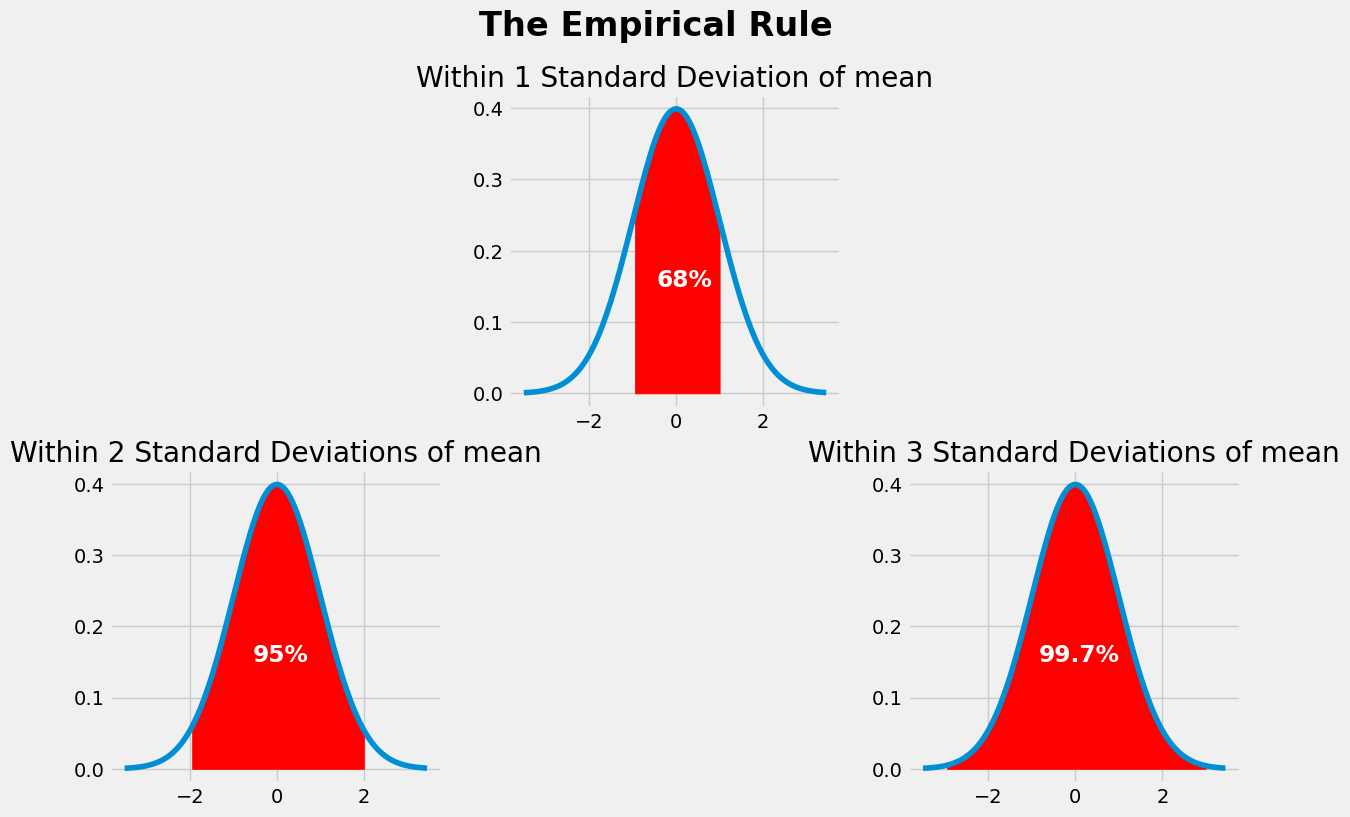

In [38]:
from hidden_demos import empirical_rule_demo
empirical_rule_demo()

### <span style="color:blue;font-weight:bold;font-size:1.1em">Use of Probability in Statistics</span>

A major field within statistics is hypothesis testing.  In the context of hypothesis testing we use probabilities to determine the outcome of the test.  

A test has a pre-set value called **The Level of Significance**, denoted $\alpha$.  The final output of most hypothesis tests is a p-value or $p$.  When $p < \alpha$ we say the result is significant.  

Usually, though not always, $$\alpha = 0.05$$This is sometimes attributed to Ron Fisher, who once said that he'd consider an event to be unlikely if it has probability of less than one-in-twenty.

#### <span style="color:blue;font-weight:bold;font-size:1.1em"> Hypothesis: Lady Tasting Tea</span>

In the Lady Tasting Tea example, the statistical hypothesis would be:

**Null Hypothesis**

$H_0 : \pi = 0.5$

**Alternative Hypothesis**

$H_a : \pi > 0.5$
    

In words, we have:

$H_0 : $ Dr. Bristol was guessing, so she had a 50-50 chance of being correct each time.

$H_a : $ Dr. Brist could taste the difference, so she had a bettern than 50-50 chance of being correct each time.